# Day 8 Tasks — Model Comparison

**Dataset:** multilingual support tickets  
**Task:** predict `priority` using combined `subject` + `body` text.

Algorithms: Logistic Regression, Decision Tree, Random Forest, Linear SVM, and Naive Bayes.

This notebook completes:
- training and test scores
- underfitting/overfitting/just-right observations
- 5-fold cross-validation
- comparison table
- best-model conclusion


In [1]:
# 1. Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

pd.set_option("display.max_columns", None)


## Load the CSV

In Colab, upload `dataset-tickets-multi-lang-4-20k(1).csv` when prompted if it is not already present.


In [2]:
# 2. Load dataset
FILE_NAME = "dataset-tickets-multi-lang-4-20k(4).csv"
paths = [FILE_NAME, f"/content/{FILE_NAME}", f"/mnt/data/{FILE_NAME}"]
csv_path = next((p for p in paths if os.path.exists(p)), None)

if csv_path is None:
    from google.colab import files
    print("Upload the dataset CSV:")
    uploaded = files.upload()
    csv_path = next(iter(uploaded.keys()))

df = pd.read_csv(csv_path)
# Use a reproducible sample so all 5-fold comparisons finish in a practical time.
if len(df) > 3000:
    df = df.sample(n=3000, random_state=42).reset_index(drop=True)
print("Shape:", df.shape)
display(df.head())
print("\nColumns:", df.columns.tolist())


Shape: (3000, 15)


,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Alarm für Datenverstoß,Es gab einen medizinischen Datenverlust aufgru...,"Ich werde den Data Breach Alert untersuchen, d...",Problem,Technical Support,high,de,Security,Breach,DataLoss,Software,Incident,Notification,Crash,Maintenance
1,Failure in Medical Data Encryption,I'm encountering difficulties with the medical...,I will help you with the medical data encrypti...,Incident,IT Support,high,en,Technical,Security,Bug,Documentation,Guidance,NaN,NaN,NaN
2,Optimierung der Datenverarbeitung,Ich möchte eine Erweiterungsvorschlag für die ...,"Sehr geehrte/r [Name],\n\nvielen Dank, dass Si...",Change,Technical Support,medium,de,Feature,Performance,Feedback,Product,NaN,NaN,NaN,NaN
3,Digitale Dienste,Welche Zahlungsmöglichkeiten gibt es?,"Sehr geehrter Kunde, wir bieten eine Reihe von...",Request,Billing and Payments,high,de,Customer,Payment,Billing,Guidance,NaN,NaN,NaN,NaN
4,NaN,"Customer Support, please address the request f...","Dear [Name], we have received your request reg...",Change,IT Support,high,en,Security,IT,Tech Support,Product,Feature,NaN,NaN,NaN



Columns: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']


## Prepare training and testing data

The target is `priority`. TF-IDF converts ticket text into numeric features. The 80/20 split is stratified.


In [3]:
# 3. Prepare X and y
work = df[["subject", "body", "priority"]].copy()
work = work.dropna(subset=["priority"])
work["subject"] = work["subject"].fillna("")
work["body"] = work["body"].fillna("")
work["text"] = (work["subject"].str.strip() + " " + work["body"].str.strip()).str.strip()
work = work[work["text"].str.len() > 0]

X = work["text"]
y = work["priority"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))
print("\nTarget distribution:")
print(y.value_counts())


Training rows: 2400
Testing rows : 600

Target distribution:
priority
medium    1212
high      1178
low        610
Name: count, dtype: int64


## Train 5 different algorithms

The main score is **F1-weighted**. Accuracy is also printed.


In [4]:
# 4. Define model pipelines
def make_pipeline(model):
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            max_features=3000,
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True
        )),
        ("model", model)
    ])

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=30, min_samples_leaf=2,
        class_weight="balanced", random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=30, max_depth=25, min_samples_leaf=2,
        class_weight="balanced", random_state=42, n_jobs=1
    ),
    "Linear SVM": LinearSVC(
        class_weight="balanced", random_state=42
    ),
    "Naive Bayes": MultinomialNB(alpha=0.5)
}

pipelines = {name: make_pipeline(model) for name, model in models.items()}
print(list(pipelines.keys()))


['Logistic Regression', 'Decision Tree', 'Random Forest', 'Linear SVM', 'Naive Bayes']


In [5]:
# 5. Train models and calculate training/test scores
results = []
fitted_models = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe

    train_pred = pipe.predict(X_train)
    test_pred = pipe.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    train_f1 = f1_score(y_train, train_pred, average="weighted")
    test_f1 = f1_score(y_test, test_pred, average="weighted")

    results.append({
        "Model": name,
        "Training Score": train_f1,
        "Test Score": test_f1,
        "Training Accuracy": train_acc,
        "Test Accuracy": test_acc
    })

    print("=" * 65)
    print(name)
    print(f"Training Accuracy    : {train_acc:.4f}")
    print(f"Test Accuracy        : {test_acc:.4f}")
    print(f"Training F1-weighted : {train_f1:.4f}")
    print(f"Test F1-weighted     : {test_f1:.4f}")


Logistic Regression
Training Accuracy    : 0.8008
Test Accuracy        : 0.4100
Training F1-weighted : 0.8008
Test F1-weighted     : 0.4117


Decision Tree
Training Accuracy    : 0.7329
Test Accuracy        : 0.4033
Training F1-weighted : 0.7329
Test F1-weighted     : 0.4035


Random Forest
Training Accuracy    : 0.9029
Test Accuracy        : 0.4300
Training F1-weighted : 0.9030
Test F1-weighted     : 0.4154


Linear SVM
Training Accuracy    : 0.9354
Test Accuracy        : 0.4167
Training F1-weighted : 0.9352
Test F1-weighted     : 0.4146


Naive Bayes
Training Accuracy    : 0.6162
Test Accuracy        : 0.4567
Training F1-weighted : 0.5941
Test F1-weighted     : 0.4169


## Diagnose underfitting, overfitting, or just right

The following practical thresholds are heuristics:
- both scores below 0.70 → underfitting
- high training score with a gap above 0.08 → overfitting
- good scores with a gap at most 0.08 → just right


In [6]:
# 6. Fit diagnosis and short note for every model
def diagnose(train_score, test_score):
    gap = train_score - test_score

    if train_score < 0.70 and test_score < 0.70:
        return "Underfitting", "Both scores are low, suggesting the model is too simple or needs better features."
    elif train_score >= 0.85 and gap > 0.08:
        return "Overfitting", "Training performance is very high but test performance is much lower."
    elif test_score >= 0.70 and abs(gap) <= 0.08:
        return "Just right", "Training and test scores are good and fairly close."
    elif gap > 0.08:
        return "Possible overfitting", "The training-test gap is noticeable, so generalization may be weaker."
    else:
        return "Reasonably balanced", "Training and test scores are close, though overall performance can improve."

for row in results:
    status, note = diagnose(row["Training Score"], row["Test Score"])
    row["Fit Status"] = status
    row["Observation"] = note
    print(f"\n{row['Model']} — {status}")
    print(note)



Logistic Regression — Possible overfitting
The training-test gap is noticeable, so generalization may be weaker.

Decision Tree — Possible overfitting
The training-test gap is noticeable, so generalization may be weaker.

Random Forest — Overfitting
Training performance is very high but test performance is much lower.

Linear SVM — Overfitting
Training performance is very high but test performance is much lower.

Naive Bayes — Underfitting
Both scores are low, suggesting the model is too simple or needs better features.


## 5-fold cross-validation

`cross_val_score(model, X_train, y_train, cv=5)` is used through each complete pipeline. Mean F1 shows average performance; standard deviation shows consistency.


In [7]:
# 7. Cross-validation for every algorithm
# This cell can take several minutes in Colab.
for row in results:
    name = row["Model"]
    cv_scores = cross_val_score(
        pipelines[name],
        X_train,
        y_train,
        cv=5,
        scoring="f1_weighted",
        n_jobs=1
    )

    row["CV Mean"] = cv_scores.mean()
    row["CV Std"] = cv_scores.std()

    print("=" * 65)
    print(name)
    print("5 fold scores:", np.round(cv_scores, 4))
    print(f"Mean score: {cv_scores.mean():.4f}")
    print(f"Std dev   : {cv_scores.std():.4f}")


Logistic Regression
5 fold scores: [0.3741 0.402  0.4139 0.4425 0.4467]
Mean score: 0.4159
Std dev   : 0.0268


Decision Tree
5 fold scores: [0.3219 0.3511 0.4    0.3447 0.3595]
Mean score: 0.3554
Std dev   : 0.0256


Random Forest
5 fold scores: [0.4305 0.4412 0.4368 0.3843 0.4597]
Mean score: 0.4305
Std dev   : 0.0251


Linear SVM
5 fold scores: [0.4143 0.403  0.4048 0.4239 0.4392]
Mean score: 0.4170
Std dev   : 0.0133


Naive Bayes
5 fold scores: [0.3604 0.4112 0.4329 0.4354 0.459 ]
Mean score: 0.4198
Std dev   : 0.0333


## Comparison table and reliability


In [8]:
# 8. Small comparison table
comparison = pd.DataFrame(results)
comparison["Reliability Score"] = comparison["CV Mean"] - comparison["CV Std"]

table = comparison[
    ["Model", "Training Score", "Test Score", "CV Mean", "CV Std", "Fit Status"]
].sort_values(["CV Mean", "Test Score"], ascending=False).reset_index(drop=True)

display(table.round(4))

most_reliable = comparison.loc[comparison["Reliability Score"].idxmax()]
print("\nMost reliable algorithm:", most_reliable["Model"])
print(f"CV mean = {most_reliable['CV Mean']:.4f}")
print(f"CV std  = {most_reliable['CV Std']:.4f}")


,Model,Training Score,Test Score,CV Mean,CV Std,Fit Status
0,Random Forest,0.9030,0.4154,0.4305,0.0251,Overfitting
1,Naive Bayes,0.5941,0.4169,0.4198,0.0333,Underfitting
2,Linear SVM,0.9352,0.4146,0.4170,0.0133,Overfitting
3,Logistic Regression,0.8008,0.4117,0.4159,0.0268,Possible overfitting
4,Decision Tree,0.7329,0.4035,0.3554,0.0256,Possible overfitting



Most reliable algorithm: Random Forest
CV mean = 0.4305
CV std  = 0.0251


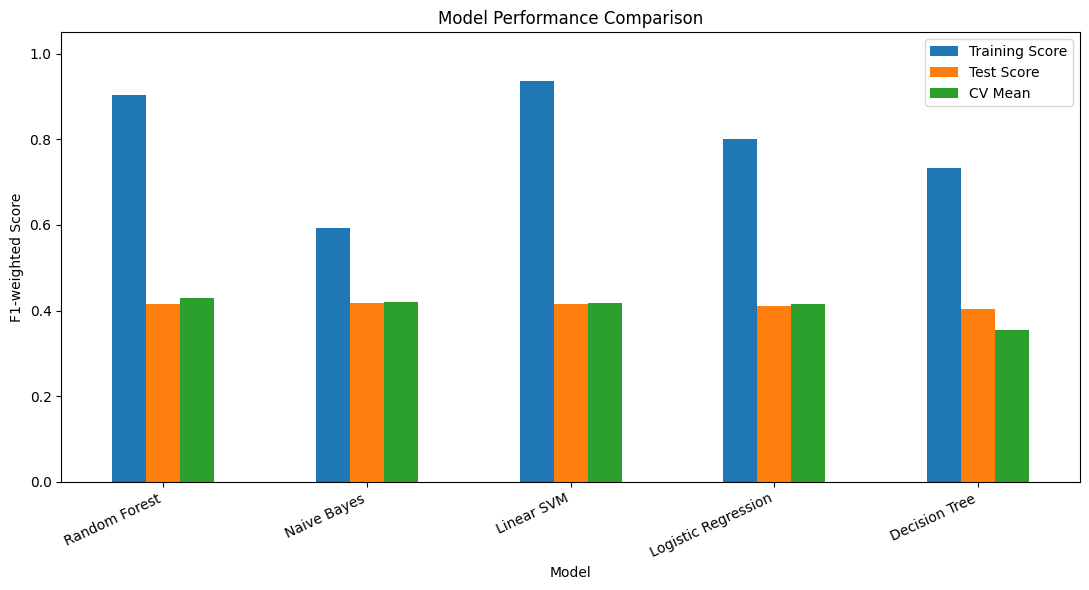

In [9]:
# 9. Visual comparison
plot_df = table.set_index("Model")[["Training Score", "Test Score", "CV Mean"]]
plot_df.plot(kind="bar", figsize=(11, 6))
plt.title("Model Performance Comparison")
plt.ylabel("F1-weighted Score")
plt.xlabel("Model")
plt.ylim(0, 1.05)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


## Final 3–5 line conclusion


In [10]:
# 10. Automatically select best overall model and write conclusion
best = comparison.sort_values(
    ["CV Mean", "Test Score"], ascending=False
).iloc[0]

print(
    f"1. {best['Model']} is the best overall model because it achieved the highest "
    f"5-fold CV mean F1 score ({best['CV Mean']:.4f}) and a test F1 score of "
    f"{best['Test Score']:.4f}."
)
print(
    f"2. Its training F1 score is {best['Training Score']:.4f}, so the fit diagnosis "
    f"is: {best['Fit Status']}."
)
print(
    f"3. Its CV standard deviation is {best['CV Std']:.4f}; a smaller value indicates "
    f"more consistent results across folds."
)
print(
    f"4. Overall, {best['Model']} gives the strongest balance of test performance, "
    f"cross-validation performance, and reliability on this dataset."
)


1. Random Forest is the best overall model because it achieved the highest 5-fold CV mean F1 score (0.4305) and a test F1 score of 0.4154.
2. Its training F1 score is 0.9030, so the fit diagnosis is: Overfitting.
3. Its CV standard deviation is 0.0251; a smaller value indicates more consistent results across folds.
4. Overall, Random Forest gives the strongest balance of test performance, cross-validation performance, and reliability on this dataset.


## Detailed classification report for the best model


In [11]:
# 11. Best model classification report
best_name = best["Model"]
best_model = fitted_models[best_name]
best_pred = best_model.predict(X_test)

print("Best model:", best_name)
print(classification_report(y_test, best_pred, zero_division=0))


Best model: Random Forest
              precision    recall  f1-score   support

        high       0.46      0.50      0.48       236
         low       0.28      0.14      0.19       122
      medium       0.44      0.51      0.47       242

    accuracy                           0.43       600
   macro avg       0.39      0.38      0.38       600
weighted avg       0.41      0.43      0.42       600



### Submission checklist

After running all cells, this notebook contains all Day 8 requirements:
- 5 algorithms
- training and test scores
- underfitting/overfitting/just-right notes
- 5-fold cross-validation mean and standard deviation
- comparison table
- most reliable algorithm
- best overall model and 3–5 line conclusion
